# Imports

In [10]:
import math, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import RandAugment
from torchvision.models import resnet18

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")


Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4


# Config

In [2]:
BATCH_SIZE    = 128
EPOCHS        = 100       # ResNets converge faster than ViT, 100 is plenty
LR            = 1e-3
WEIGHT_DECAY  = 0.05
WARMUP_EPOCHS = 5
PATIENCE      = 20
NUM_CLASSES   = 10

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CLASSES      = ["airplane","automobile","bird","cat","deer",
                "dog","frog","horse","ship","truck"]

print(f"Epochs     : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"LR         : {LR}  (warmup {WARMUP_EPOCHS} → cosine decay)")
print(f"Patience   : {PATIENCE}")


Epochs     : 100
Batch size : 128
LR         : 0.001  (warmup 5 → cosine decay)
Patience   : 20


# Dataset

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")


100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Train samples : 50,000
Test  samples : 10,000


# ResNet Builder

In [11]:
def make_resnet_cifar(arch="resnet18"):
    model = resnet18(weights=None)   # from scratch, no pretrained weights

    # Fix for small images
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


resnet18_model = make_resnet_cifar("resnet18").to(DEVICE)


r18_params = sum(p.numel() for p in resnet18_model.parameters())

print(f"ResNet-18 : {r18_params/1e6:.2f}M parameters")


ResNet-18 : 11.17M parameters


# MixUp and CutMix

In [5]:
def mixup(images, labels, alpha=0.4):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def cutmix(images, labels, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = images.shape
    idx = torch.randperm(B, device=images.device)
    cut_h = int(H * math.sqrt(1 - lam))
    cut_w = int(W * math.sqrt(1 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, x2 = max(cx - cut_w//2, 0), min(cx + cut_w//2, W)
    y1, y2 = max(cy - cut_h//2, 0), min(cy + cut_h//2, H)
    mixed  = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam    = 1 - (y2-y1)*(x2-x1)/(H*W)
    return mixed, labels, labels[idx], lam

def mix_loss(criterion, logits, la, lb, lam):
    return lam * criterion(logits, la) + (1 - lam) * criterion(logits, lb)


# Train and Evaluate

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        r = random.random()
        if r < 0.5:
            images, la, lb, lam = mixup(images, labels)
            use_mix = True
        elif r < 1.0:
            images, la, lb, lam = cutmix(images, labels)
            use_mix = True
        else:
            use_mix = False

        optimizer.zero_grad()
        logits = model(images)
        loss   = mix_loss(criterion, logits, la, lb, lam) if use_mix else criterion(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits  = model(images)
        loss    = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


# Training Runner

In [7]:
def run_training(model, model_name, save_path):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                                  weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

    history        = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}
    best_acc       = 0.0
    patience_count = 0
    t_start        = time.time()

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  Params : {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} {'Tr Loss':>9} {'Tr Acc':>8} {'Te Loss':>9} {'Te Acc':>8} {'Time':>6}")
    print("─" * 52)

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if te_acc > best_acc:
            best_acc       = te_acc
            patience_count = 0
            torch.save(model.state_dict(), save_path)
            marker = "◀ best"
        else:
            patience_count += 1
            marker = ""

        print(f"{epoch:>6} {tr_loss:>9.4f} {tr_acc:>8.3f} "
              f"{te_loss:>9.4f} {te_acc:>8.3f} {time.time()-t0:>5.1f}s  {marker}")

        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    history["best_acc"]   = best_acc
    history["total_time"] = (time.time() - t_start) / 60
    history["epochs_run"] = len(history["train_acc"])
    history["params_M"]   = sum(p.numel() for p in model.parameters()) / 1e6

    print(f"\nDone in {history['total_time']:.1f} min")
    print(f"Best accuracy : {best_acc*100:.2f}%")
    return history


# Train ResNet-18

In [8]:

r18_history = run_training(resnet18_model, "ResNet-18", "best_resnet18.pth")


  ResNet-18
  Params : 11.17M
 Epoch   Tr Loss   Tr Acc   Te Loss   Te Acc   Time
────────────────────────────────────────────────────
     1    2.2209    0.164    1.9375    0.328  66.3s  ◀ best
     2    2.0369    0.261    1.5674    0.504  59.6s  ◀ best
     3    1.8742    0.332    1.4151    0.586  59.7s  ◀ best
     4    1.7847    0.380    1.2605    0.662  60.3s  ◀ best
     5    1.7133    0.419    1.3887    0.637  59.3s  
     6    1.6473    0.437    1.1691    0.721  59.7s  ◀ best
     7    1.5962    0.430    1.1063    0.736  59.7s  ◀ best
     8    1.5893    0.455    1.1288    0.745  58.8s  ◀ best
     9    1.5565    0.491    1.0434    0.774  59.6s  ◀ best
    10    1.5063    0.485    1.0057    0.789  60.4s  ◀ best
    11    1.5164    0.501    1.0179    0.791  59.0s  ◀ best
    12    1.4468    0.522    0.9186    0.845  60.7s  ◀ best
    13    1.4387    0.505    0.8640    0.851  59.1s  ◀ best
    14    1.4472    0.519    0.8900    0.852  59.5s  ◀ best
    15    1.4353    0.499    0

# Per class Accuracy

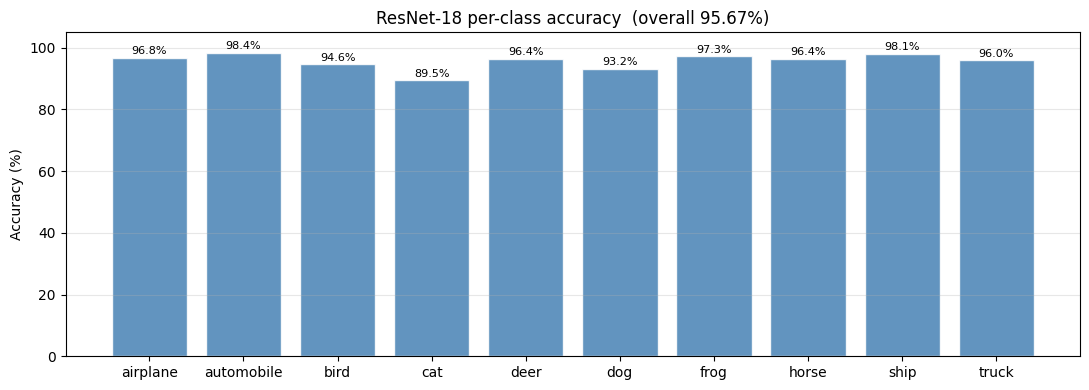


Class          ResNet-18
─────────────────────────
airplane           96.8%
automobile         98.4%
bird               94.6%
cat                89.5%
deer               96.4%
dog                93.2%
frog               97.3%
horse              96.4%
ship               98.1%
truck              96.0%


In [13]:

@torch.no_grad()
def per_class_accuracy(model, save_path, loader, device):
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    correct = torch.zeros(10)
    total   = torch.zeros(10)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for c in range(10):
            mask = labels == c
            correct[c] += (preds[mask] == c).sum().item()
            total[c]   += mask.sum().item()
    return (correct / total * 100).numpy()


r18_class_acc = per_class_accuracy(resnet18_model, "best_resnet18.pth", test_loader, DEVICE)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(CLASSES, r18_class_acc, color="steelblue", alpha=0.85, edgecolor="white")
ax.set_ylim(0, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"ResNet-18 per-class accuracy  (overall {r18_history['best_acc']*100:.2f}%)")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, r18_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n{'Class':<12}  {'ResNet-18':>10}")
print("─" * 25)
for cls, acc in zip(CLASSES, r18_class_acc):
    print(f"{cls:<12}  {acc:>9.1f}%")


# Leanring Curves

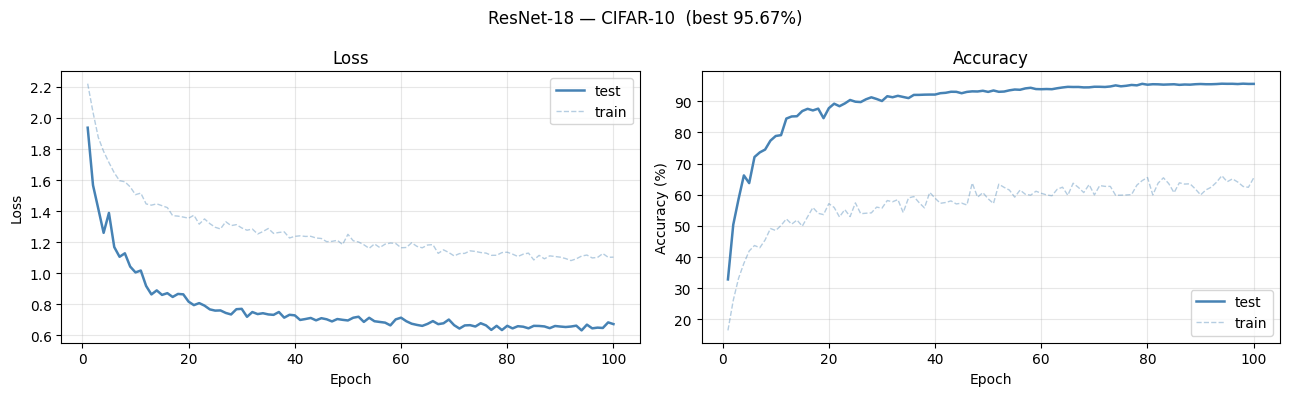

In [15]:
ep = range(1, r18_history["epochs_run"] + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ep, r18_history["test_loss"],  color="steelblue", linewidth=1.8, label="test")
ax1.plot(ep, r18_history["train_loss"], color="steelblue", linewidth=1.0, alpha=0.4, linestyle="--", label="train")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, [a*100 for a in r18_history["test_acc"]],  color="steelblue", linewidth=1.8, label="test")
ax2.plot(ep, [a*100 for a in r18_history["train_acc"]], color="steelblue", linewidth=1.0, alpha=0.4, linestyle="--", label="train")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f"ResNet-18 — CIFAR-10  (best {r18_history['best_acc']*100:.2f}%)", fontsize=12)
plt.tight_layout()
plt.show()

# Comparison -> ResNet VS ViT


  CIFAR-10 Final Results
  Same dataset · same augmentation · same training recipe
  Model           Accuracy    Params      Time   Epochs
  ────────────── ─────────  ────────  ────────  ───────
  ResNet-18         95.67%     11.2M     99.7m     100ep
  ViT               89.11%      5.7M    249.3m     200ep


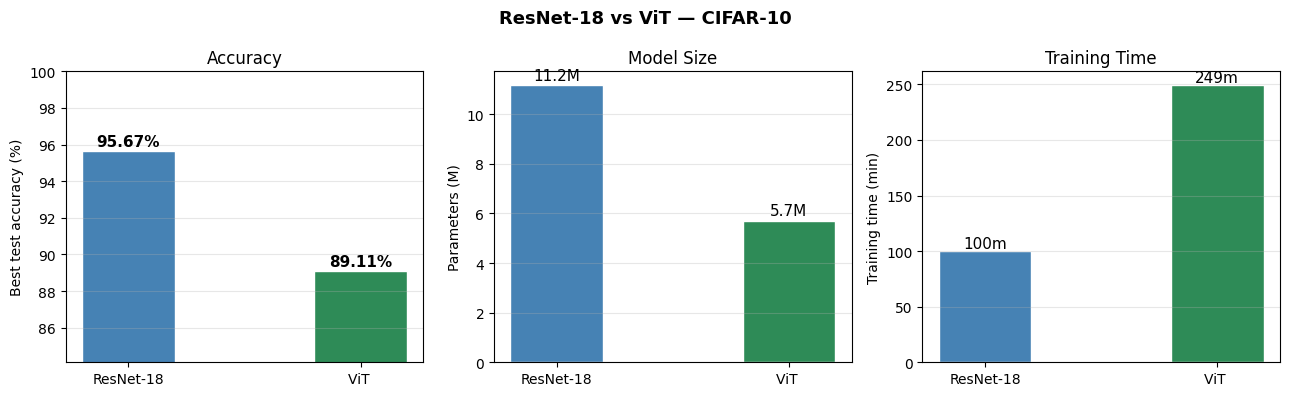


Winner on accuracy : ResNet-18  (95.67%)

Why CNNs typically beat ViT on CIFAR-10:
  CNNs have translation equivariance and locality built in.
  ViT has to learn these from data — needs much more of it.
  Crossover point is typically 100M+ training samples.


In [17]:
VIT_BEST_ACC = 89.11
VIT_PARAMS_M = 5.7
VIT_TIME_MIN = 249.3
VIT_EPOCHS   = 200


results = {
    "ResNet-18"  : {"acc": r18_history["best_acc"]*100, "params": r18_history["params_M"],
                    "time": r18_history["total_time"],  "epochs": r18_history["epochs_run"]},
    "ViT ": {"acc": VIT_BEST_ACC, "params": VIT_PARAMS_M,
                    "time": VIT_TIME_MIN, "epochs": VIT_EPOCHS},
}

#  Summary table
print(f"\n{'='*60}")
print(f"  CIFAR-10 Final Results")
print(f"  Same dataset · same augmentation · same training recipe")
print(f"{'='*60}")
print(f"  {'Model':<14} {'Accuracy':>9}  {'Params':>8}  {'Time':>8}  {'Epochs':>7}")
print(f"  {'─'*14} {'─'*9}  {'─'*8}  {'─'*8}  {'─'*7}")
for name, r in results.items():
    print(f"  {name:<14} {r['acc']:>8.2f}%  {r['params']:>7.1f}M  "
          f"{r['time']:>7.1f}m  {r['epochs']:>6}ep")
print(f"{'='*60}")

#  Bar charts
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names  = list(results.keys())
colors = ["steelblue", "seagreen"]

accs = [results[n]["acc"] for n in names]
bars = axes[0].bar(names, accs, color=colors, edgecolor="white", width=0.4)
axes[0].set_ylim(min(accs) - 5, 100)
axes[0].set_ylabel("Best test accuracy (%)")
axes[0].set_title("Accuracy")
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{acc:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

params = [results[n]["params"] for n in names]
axes[1].bar(names, params, color=colors, edgecolor="white", width=0.4)
axes[1].set_ylabel("Parameters (M)")
axes[1].set_title("Model Size")
axes[1].grid(axis="y", alpha=0.3)
for i, p in enumerate(params):
    axes[1].text(i, p + 0.1, f"{p:.1f}M", ha="center", va="bottom", fontsize=11)

times = [results[n]["time"] for n in names]
axes[2].bar(names, times, color=colors, edgecolor="white", width=0.4)
axes[2].set_ylabel("Training time (min)")
axes[2].set_title("Training Time")
axes[2].grid(axis="y", alpha=0.3)
for i, t in enumerate(times):
    axes[2].text(i, t + 0.5, f"{t:.0f}m", ha="center", va="bottom", fontsize=11)

plt.suptitle("ResNet-18 vs ViT — CIFAR-10", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#  Takeaway
best = max(results, key=lambda n: results[n]["acc"])
print(f"\nWinner on accuracy : {best}  ({results[best]['acc']:.2f}%)")
print(f"\nWhy CNNs typically beat ViT on CIFAR-10:")
print(f"  CNNs have translation equivariance and locality built in.")
print(f"  ViT has to learn these from data — needs much more of it.")
print(f"  Crossover point is typically 100M+ training samples.")